In [1]:

import os
import gc
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 11
})

PALETTE = ["#7C3AED", "#06B6D4", "#F59E0B", "#EF4444", "#10B981", "#3B82F6"]

def section(title, subtitle=""):
    display(HTML(
        f'''
        <div style="margin:24px 0 14px;padding:16px 20px;border-radius:18px;
        background:linear-gradient(135deg,#111827,#312E81);color:white;
        box-shadow:0 8px 24px rgba(0,0,0,.14)">
        <div style="font-size:25px;font-weight:800;letter-spacing:.2px">{title}</div>
        <div style="margin-top:5px;font-size:13px;opacity:.86">{subtitle}</div>
        </div>
        '''
    ))

def metric_cards(items):
    cards = "".join(
        f'''
        <div style="flex:1;min-width:150px;padding:16px 18px;border-radius:16px;
        background:linear-gradient(135deg,{PALETTE[i%len(PALETTE)]}22,#ffffff);
        border:1px solid {PALETTE[i%len(PALETTE)]}55">
        <div style="font-size:12px;opacity:.72">{k}</div>
        <div style="font-size:25px;font-weight:800;margin-top:5px">{v}</div>
        </div>
        '''
        for i,(k,v) in enumerate(items)
    )
    display(HTML(f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0 20px">{cards}</div>'))

section("Deep RNN Lab", "Stacked RNNs, Deep LSTM, Deep GRU, IMDB sentiment classification and model diagnostics")

gpu_devices = tf.config.list_physical_devices("GPU")
metric_cards([
    ("TensorFlow", tf.__version__),
    ("GPU devices", len(gpu_devices)),
    ("Seed", SEED),
    ("Backend", "TensorFlow")
])


In [2]:

section("Configuration", "Experiment controls matching the core setup from the source material")

VOCAB_SIZE = 10000
MAX_LEN = 100
EMBED_DIM = 32
UNITS = 5
EPOCHS = 5
BATCH_SIZE = 128
VAL_SIZE = 5000
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None
RUN_BASELINES = False

print({
    "vocab_size": VOCAB_SIZE,
    "max_sequence_length": MAX_LEN,
    "embedding_dimension": EMBED_DIM,
    "recurrent_units_per_layer": UNITS,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "validation_size": VAL_SIZE,
    "run_shallow_baselines": RUN_BASELINES
})


{'vocab_size': 10000, 'max_sequence_length': 100, 'embedding_dimension': 32, 'recurrent_units_per_layer': 5, 'epochs': 5, 'batch_size': 128, 'validation_size': 5000, 'run_shallow_baselines': False}


In [3]:

section("Load the IMDB Dataset", "Binary sentiment classification with a 10,000-word vocabulary and sequences capped at 100 tokens")

(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

train_lengths = np.array([len(x) for x in x_train_raw])
test_lengths = np.array([len(x) for x in x_test_raw])

if MAX_TRAIN_SAMPLES is not None:
    x_train_raw = x_train_raw[:MAX_TRAIN_SAMPLES]
    y_train = y_train[:MAX_TRAIN_SAMPLES]
    train_lengths = train_lengths[:MAX_TRAIN_SAMPLES]

if MAX_TEST_SAMPLES is not None:
    x_test_raw = x_test_raw[:MAX_TEST_SAMPLES]
    y_test = y_test[:MAX_TEST_SAMPLES]
    test_lengths = test_lengths[:MAX_TEST_SAMPLES]

x_train = pad_sequences(x_train_raw, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test = pad_sequences(x_test_raw, maxlen=MAX_LEN, padding="pre", truncating="pre")

split_at = len(x_train) - VAL_SIZE
x_fit, x_val = x_train[:split_at], x_train[split_at:]
y_fit, y_val = np.asarray(y_train[:split_at]), np.asarray(y_train[split_at:])

metric_cards([
    ("Train", f"{len(x_fit):,}"),
    ("Validation", f"{len(x_val):,}"),
    ("Test", f"{len(x_test):,}"),
    ("Max tokens", MAX_LEN)
])

print("x_fit:", x_fit.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)


x_fit: (20000, 100)
x_val: (5000, 100)
x_test: (25000, 100)


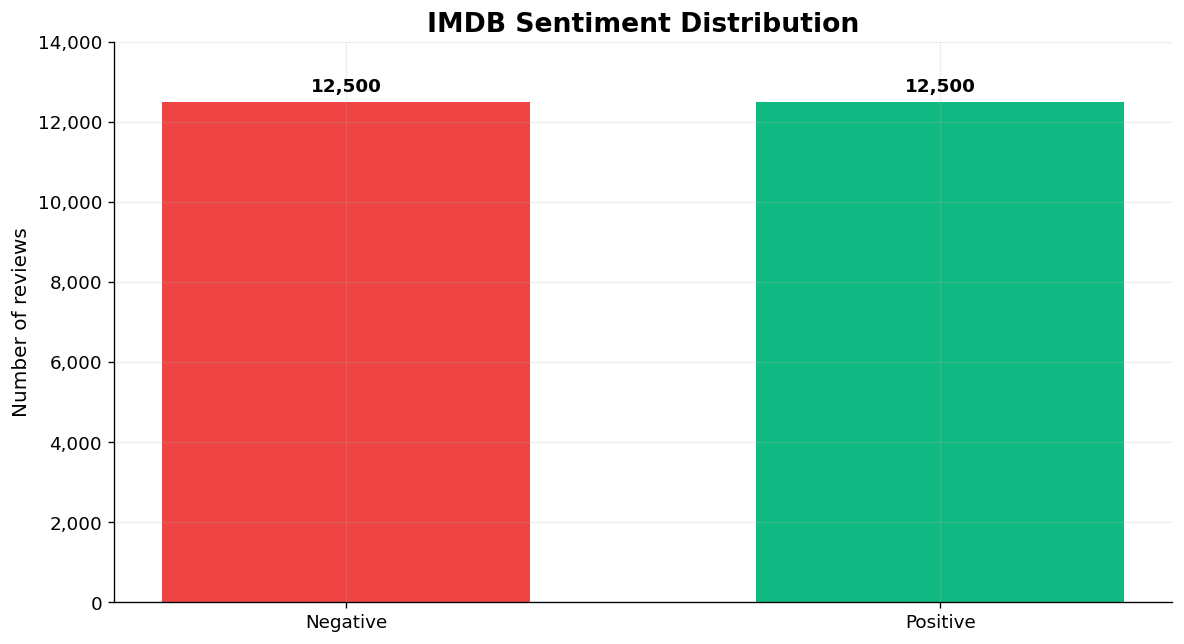

In [4]:

section("Dataset Balance", "Positive and negative sentiment distribution")

counts = np.bincount(y_train.astype(int), minlength=2)
labels = ["Negative", "Positive"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(labels, counts, color=[PALETTE[3], PALETTE[4]], width=.62)
ax.set_title("IMDB Sentiment Distribution")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
for bar, value in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, value + counts.max()*0.02, f"{value:,}", ha="center", fontweight="bold")
ax.set_ylim(0, counts.max()*1.12)
plt.tight_layout()
plt.show()

metric_cards([
    ("Negative", f"{counts[0]/counts.sum():.1%}"),
    ("Positive", f"{counts[1]/counts.sum():.1%}"),
    ("Total", f"{counts.sum():,}")
])


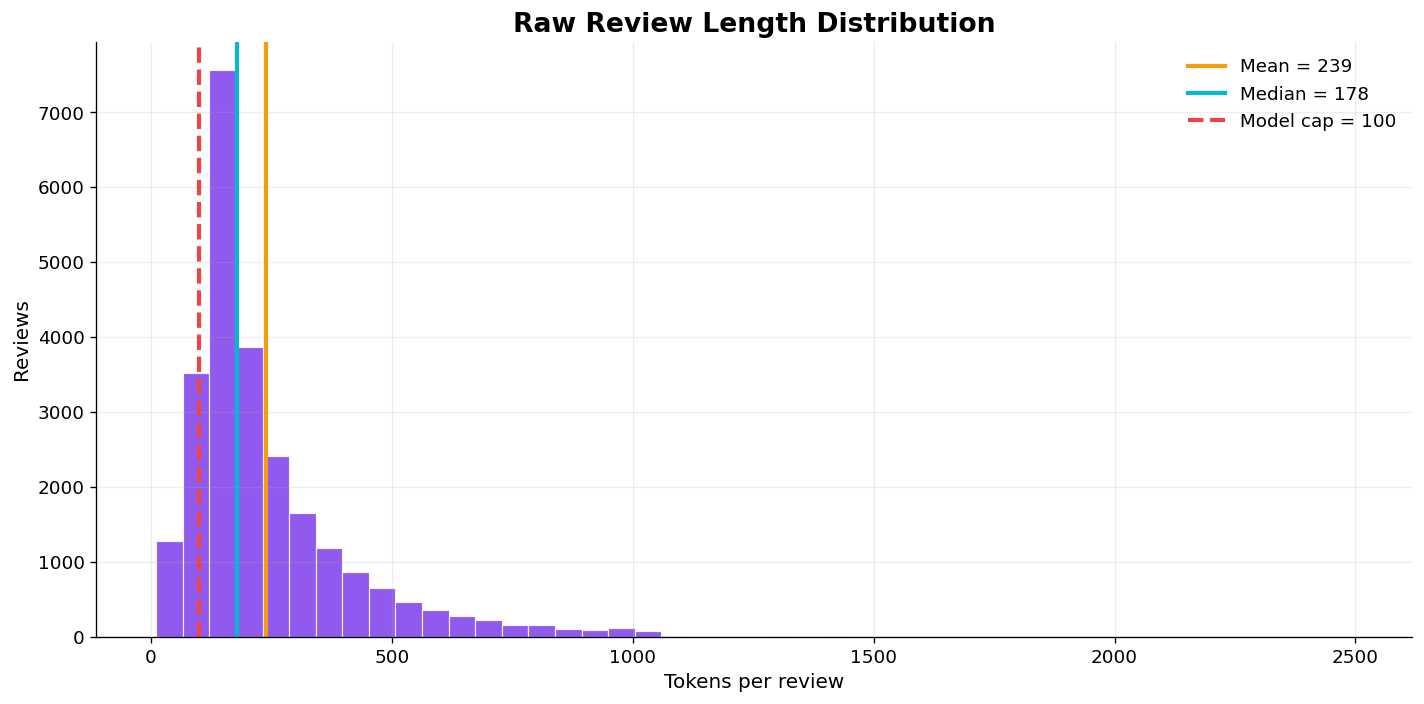

In [5]:

section("Sequence Length Analysis", "The model receives exactly 100 positions after padding and truncation")

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(train_lengths, bins=45, color=PALETTE[0], alpha=.84, edgecolor="white", linewidth=.7)
ax.axvline(train_lengths.mean(), color=PALETTE[2], linewidth=2.5, label=f"Mean = {train_lengths.mean():.0f}")
ax.axvline(np.median(train_lengths), color=PALETTE[1], linewidth=2.5, label=f"Median = {np.median(train_lengths):.0f}")
ax.axvline(MAX_LEN, color=PALETTE[3], linewidth=2.5, linestyle="--", label=f"Model cap = {MAX_LEN}")
ax.set_title("Raw Review Length Distribution")
ax.set_xlabel("Tokens per review")
ax.set_ylabel("Reviews")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

clip_rate = np.mean(train_lengths > MAX_LEN)
short_rate = np.mean(train_lengths < MAX_LEN)
metric_cards([
    ("Mean raw length", f"{train_lengths.mean():.0f}"),
    ("Median raw length", f"{np.median(train_lengths):.0f}"),
    ("Longer than cap", f"{clip_rate:.1%}"),
    ("Shorter than cap", f"{short_rate:.1%}")
])


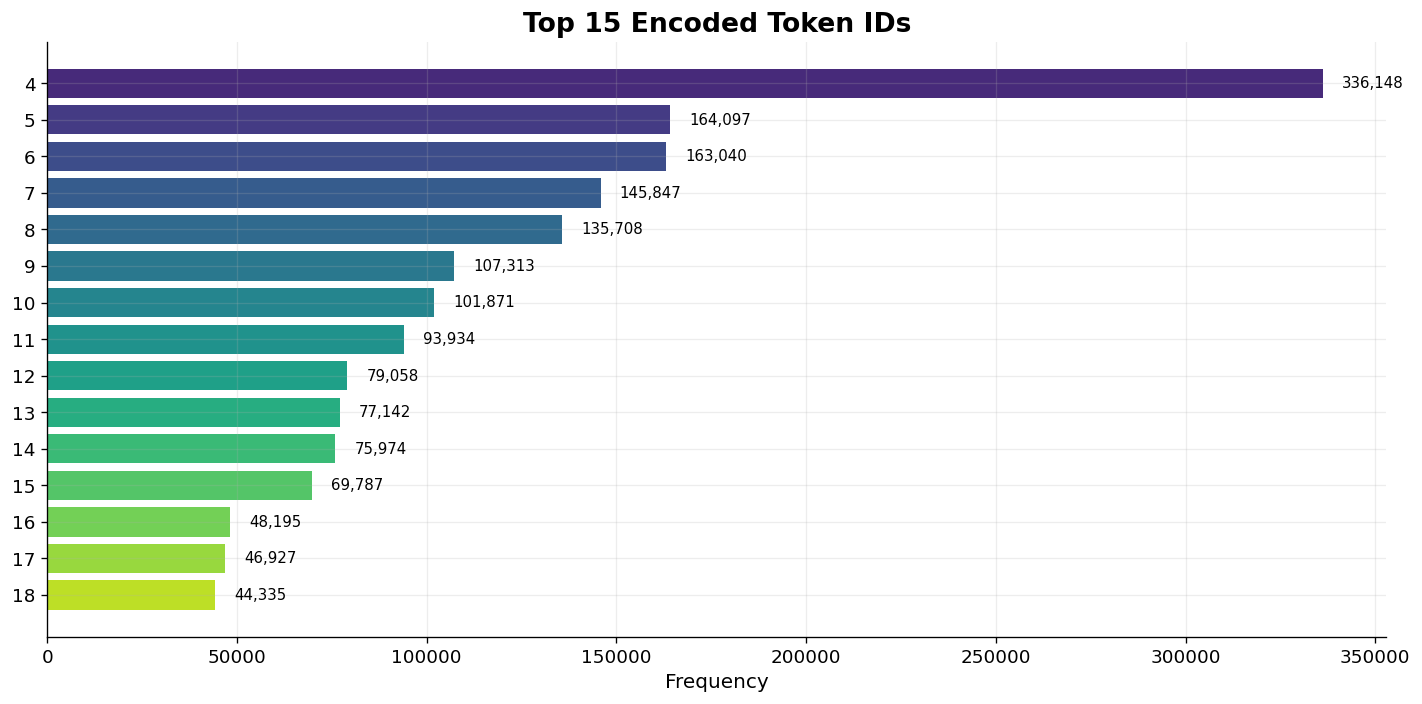

In [6]:

section("Token Frequency Overview", "Most frequent encoded tokens in the training corpus")

flat_tokens = np.concatenate(x_train_raw)
freq = np.bincount(flat_tokens, minlength=VOCAB_SIZE)
freq[:4] = 0
top_ids = np.argsort(freq)[-15:][::-1]
top_freqs = freq[top_ids]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(np.arange(len(top_ids))[::-1], top_freqs, color=plt.cm.viridis(np.linspace(.12,.9,len(top_ids))))
ax.set_yticks(np.arange(len(top_ids))[::-1])
ax.set_yticklabels([str(i) for i in top_ids])
ax.set_title("Top 15 Encoded Token IDs")
ax.set_xlabel("Frequency")
for bar, val in zip(bars, top_freqs):
    ax.text(val + top_freqs.max()*0.015, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


In [7]:

section("Decode Example Reviews", "Mapping IMDb integer sequences back to readable tokens")

word_index = imdb.get_word_index()
index_word = {value + 3: key for key, value in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(index_word.get(int(token), "<UNK>") for token in sequence)

sample_indices = [0, 1, 2, 3]
for idx in sample_indices:
    raw_text = decode_review(x_train_raw[idx])
    sentiment = "Positive" if y_train[idx] == 1 else "Negative"
    print(f"Review {idx+1} | {sentiment}\n{raw_text[:900]}\n")


Review 1 | Positive
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up ar

Review 2 | Negative
<START> big hair big boobs bad music and a giant safety pi

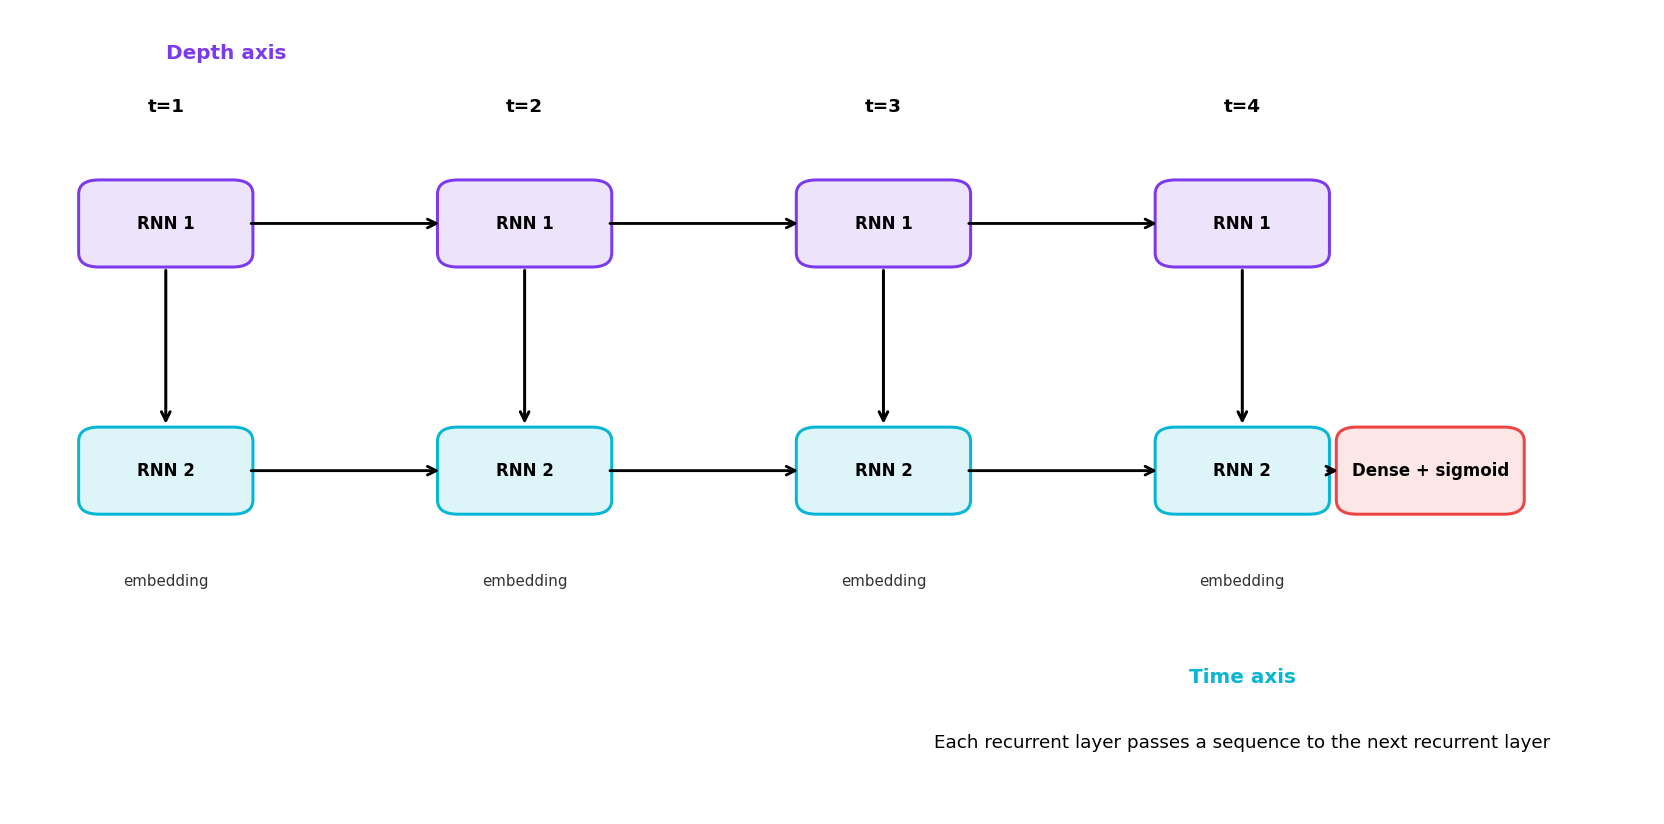

In [8]:

section("Deep RNN Architecture", "Time moves left-to-right while recurrent depth moves top-to-bottom")

def draw_deep_rnn_architecture(timesteps=4):
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, timesteps*2.1 + 1.2)
    ax.set_ylim(-1.2, 5.6)
    ax.axis("off")
    x_positions = np.arange(timesteps) * 2.1 + .9
    y_positions = [3.8, 1.7]
    layer_colors = [PALETTE[0], PALETTE[1]]
    for layer_idx, y in enumerate(y_positions):
        for t, x in enumerate(x_positions):
            patch = FancyBboxPatch(
                (x-.48, y-.34), .96, .68,
                boxstyle="round,pad=.03,rounding_size=.12",
                linewidth=1.8, edgecolor=layer_colors[layer_idx],
                facecolor=layer_colors[layer_idx] + "22"
            )
            ax.add_patch(patch)
            ax.text(x, y, f"RNN {layer_idx+1}", ha="center", va="center", fontweight="bold", fontsize=10)
            if t > 0:
                arrow = FancyArrowPatch(
                    (x_positions[t-1]+.48, y), (x-.48, y),
                    arrowstyle="->", mutation_scale=13, linewidth=1.7,
                    connectionstyle="arc3,rad=0"
                )
                ax.add_patch(arrow)
    for t, x in enumerate(x_positions):
        arrow = FancyArrowPatch(
            (x, 3.43), (x, 2.07),
            arrowstyle="->", mutation_scale=13, linewidth=1.8
        )
        ax.add_patch(arrow)
        ax.text(x, 4.75, f"t={t+1}", ha="center", fontsize=11, fontweight="bold")
        ax.text(x, .72, "embedding", ha="center", fontsize=9, alpha=.8)
    output_x = x_positions[-1] + 1.1
    out = FancyBboxPatch(
        (output_x-.52, 1.36), 1.04, .68,
        boxstyle="round,pad=.03,rounding_size=.12",
        linewidth=1.8, edgecolor=PALETTE[3], facecolor=PALETTE[3]+"22"
    )
    ax.add_patch(out)
    ax.text(output_x, 1.7, "Dense + sigmoid", ha="center", va="center", fontweight="bold", fontsize=10)
    ax.add_patch(FancyArrowPatch(
        (x_positions[-1]+.48, 1.7), (output_x-.52, 1.7),
        arrowstyle="->", mutation_scale=13, linewidth=1.8
    ))
    ax.text(.9, 5.2, "Depth axis", fontsize=12, fontweight="bold", color=PALETTE[0])
    ax.text(x_positions[-1], -.1, "Time axis", fontsize=12, fontweight="bold", color=PALETTE[1], ha="center")
    ax.text(x_positions[-1], -0.65, "Each recurrent layer passes a sequence to the next recurrent layer", ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

draw_deep_rnn_architecture()


In [9]:

section("Return Sequences", "Every non-final recurrent layer must preserve the time dimension so the next recurrent layer can receive a sequence")

def build_deep_model(kind, name):
    recurrent = {
        "SimpleRNN": layers.SimpleRNN,
        "LSTM": layers.LSTM,
        "GRU": layers.GRU
    }[kind]
    inputs = layers.Input(shape=(MAX_LEN,), dtype="int32", name="tokens")
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="embedding")(inputs)
    x = recurrent(UNITS, return_sequences=True, name=f"{kind.lower()}_1")(x)
    x = recurrent(UNITS, return_sequences=False, name=f"{kind.lower()}_2")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="sentiment")(x)
    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"), tf.keras.metrics.AUC(name="auc")]
    )
    return model

shape_model = build_deep_model("SimpleRNN", "deep_simplernn_shapes")

for layer in shape_model.layers:
    print(f"{layer.name:24s} {str(layer.output.shape):24s} params={layer.count_params():,}")

batch_probe = shape_model(x_train[:2], training=False)
print("Final batch output shape:", batch_probe.shape)


tokens                   (None, 100)              params=0
embedding                (None, 100, 32)          params=320,000
simplernn_1              (None, 100, 5)           params=190
simplernn_2              (None, 5)                params=55
sentiment                (None, 1)                params=6
Final batch output shape: (2, 1)


Deep SimpleRNN


Layer,Type,Parameters,Share
tokens,InputLayer,0,0.0%
embedding,Embedding,"320,000",99.9%
simplernn_1,SimpleRNN,190,0.1%
simplernn_2,SimpleRNN,55,0.0%
sentiment,Dense,6,0.0%


Total parameters: 320,251

Deep LSTM


Layer,Type,Parameters,Share
tokens,InputLayer,0,0.0%
embedding,Embedding,"320,000",99.7%
lstm_1,LSTM,760,0.2%
lstm_2,LSTM,220,0.1%
sentiment,Dense,6,0.0%


Total parameters: 320,986

Deep GRU


Layer,Type,Parameters,Share
tokens,InputLayer,0,0.0%
embedding,Embedding,"320,000",99.8%
gru_1,GRU,585,0.2%
gru_2,GRU,180,0.1%
sentiment,Dense,6,0.0%


Total parameters: 320,771



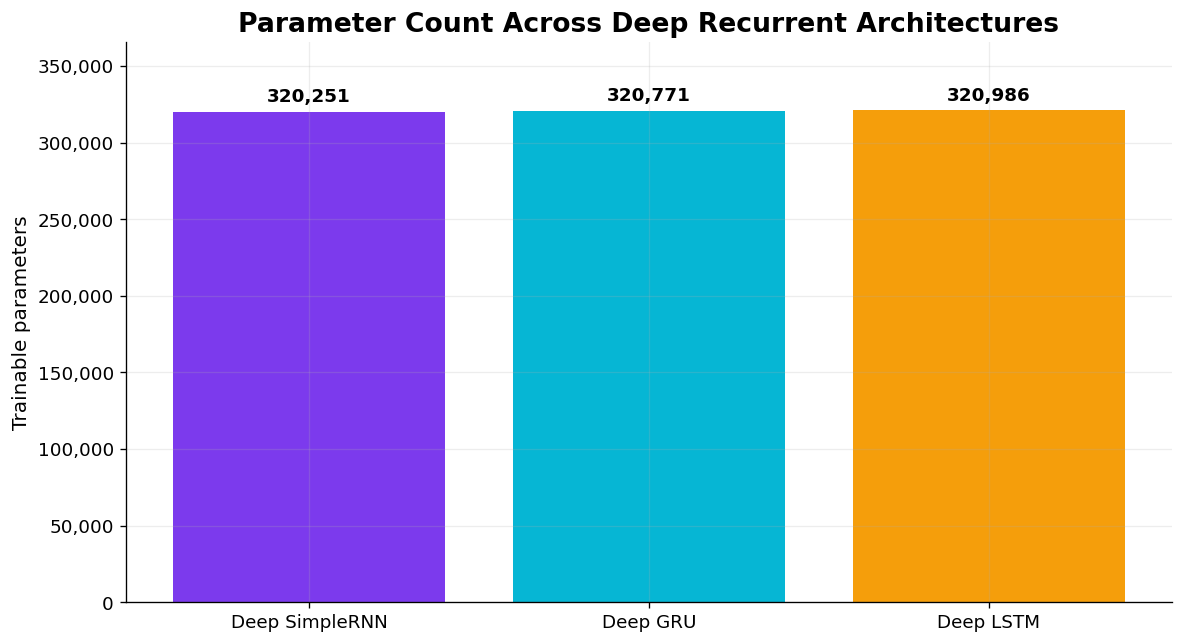

12069

In [10]:

section("Parameter Breakdown", "The source example uses a 10,000-word vocabulary, 32-dimensional embeddings and two recurrent layers with 5 units")

def layer_parameter_table(model):
    rows = []
    for layer in model.layers:
        rows.append({
            "Layer": layer.name,
            "Type": layer.__class__.__name__,
            "Parameters": layer.count_params()
        })
    df = pd.DataFrame(rows)
    df["Share"] = df["Parameters"] / df["Parameters"].sum()
    return df

probe_models = {
    "Deep SimpleRNN": build_deep_model("SimpleRNN", "probe_simplernn"),
    "Deep LSTM": build_deep_model("LSTM", "probe_lstm"),
    "Deep GRU": build_deep_model("GRU", "probe_gru")
}

for model_name, model in probe_models.items():
    table = layer_parameter_table(model)
    print(model_name)
    display(table.style.format({"Parameters": "{:,}", "Share": "{:.1%}"}).hide(axis="index"))
    print(f"Total parameters: {model.count_params():,}\n")

param_totals = pd.Series({name: model.count_params() for name, model in probe_models.items()}).sort_values()

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(param_totals.index, param_totals.values, color=[PALETTE[0], PALETTE[1], PALETTE[2]])
ax.set_title("Parameter Count Across Deep Recurrent Architectures")
ax.set_ylabel("Trainable parameters")
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")
for bar, val in zip(bars, param_totals.values):
    ax.text(bar.get_x()+bar.get_width()/2, val*1.02, f"{val:,}", ha="center", fontweight="bold")
ax.set_ylim(0, param_totals.max()*1.14)
plt.tight_layout()
plt.show()

del probe_models, shape_model
gc.collect()


In [11]:

section("Build the Deep Models", "Two stacked recurrent layers followed by a sigmoid output layer")

models = {
    "Deep SimpleRNN": build_deep_model("SimpleRNN", "deep_simplernn"),
    "Deep LSTM": build_deep_model("LSTM", "deep_lstm"),
    "Deep GRU": build_deep_model("GRU", "deep_gru")
}

for name, model in models.items():
    print(f"{name}: {model.count_params():,} parameters")


Deep SimpleRNN: 320,251 parameters
Deep LSTM: 320,986 parameters
Deep GRU: 320,771 parameters


In [12]:

section("Model Architectures", "Compact Keras summaries for the three stacked recurrent models")

for name, model in models.items():
    print("="*88)
    print(name)
    print("="*88)
    model.summary()


Deep SimpleRNN


Model: "deep_simplernn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tokens (InputLayer)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simplernn_1 (SimpleRNN)         │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simplernn_2 (SimpleRNN)         │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment (Dense)               │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,251 (1.22 MB)

 Trainable params: 320,251 (1.22 MB)

...

Model: "deep_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tokens (InputLayer)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 5)         │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment (Dense)               │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,771 (1.22 MB)

 Trainable params: 320,771 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:

section("Training", "Early stopping and learning-rate reduction keep the experiment stable")

callbacks_factory = lambda: [
    EarlyStopping(monitor="val_accuracy", patience=2, mode="max", restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=.5, patience=1, min_lr=1e-5, verbose=1)
]

histories = {}
timings = {}

for name, model in models.items():
    print("="*88)
    print(name)
    print("="*88)
    start = time.perf_counter()
    history = model.fit(
        x_fit, y_fit,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_factory(),
        verbose=1
    )
    timings[name] = time.perf_counter() - start
    histories[name] = history.history
    print(f"Training time: {timings[name]/60:.2f} minutes")


Deep SimpleRNN
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6008 - auc: 0.6575 - loss: 0.6571 - val_accuracy: 0.7776 - val_auc: 0.8544 - val_loss: 0.5237 - learning_rate: 0.0010
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8251 - auc: 0.8985 - loss: 0.4364 - val_accuracy: 0.8226 - val_auc: 0.8899 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 3/5
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8805 - auc: 0.9434 - loss: 0.3341
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8909 - auc: 0.9489 - loss: 0.3104 - val_accuracy: 0.8066 - val_auc: 0.8840 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9273 - auc: 0.9722 - loss: 0.2284 - val_accuracy: 0.8330 - val_auc: 0.8922 - val_loss: 0.4218 - learning_rate: 5.0000e-04
Epoch 5/5
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9437 - auc: 

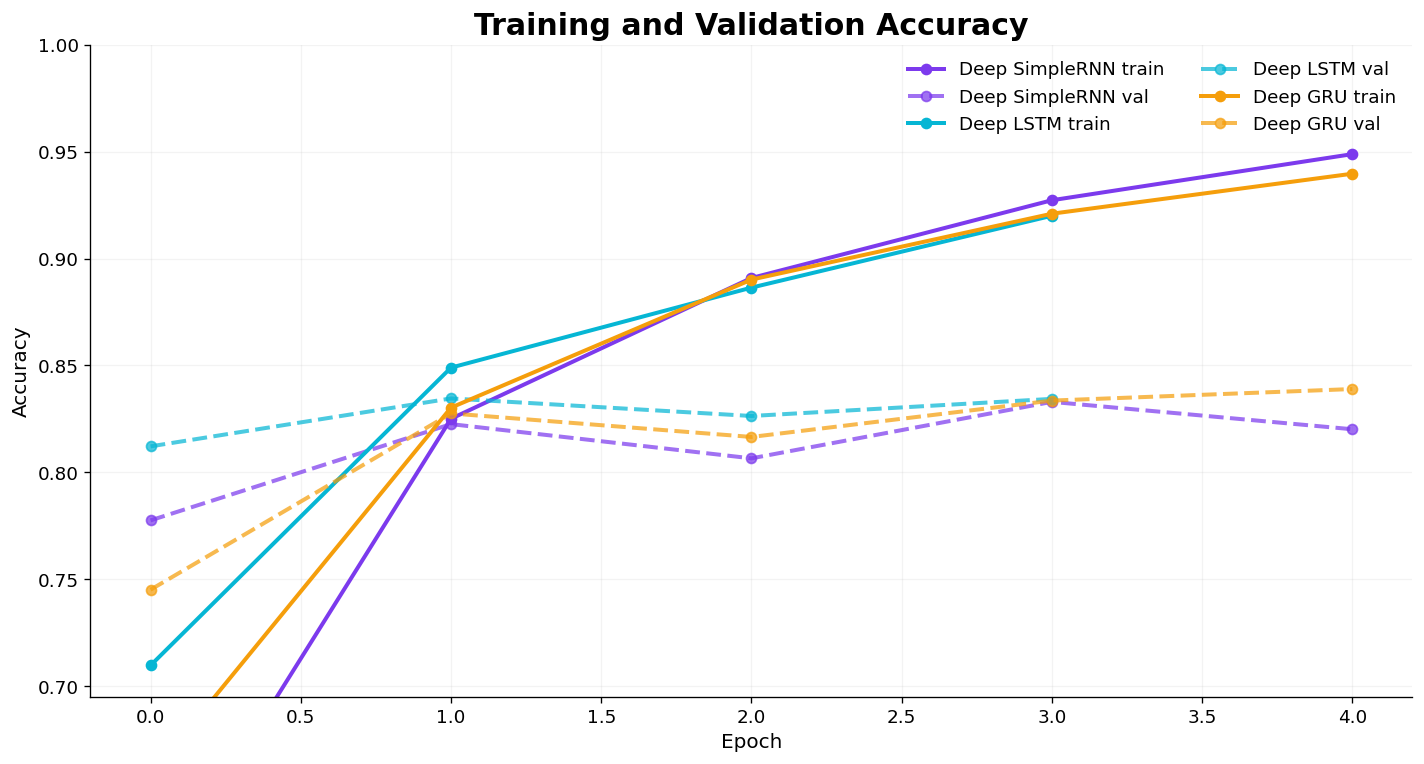

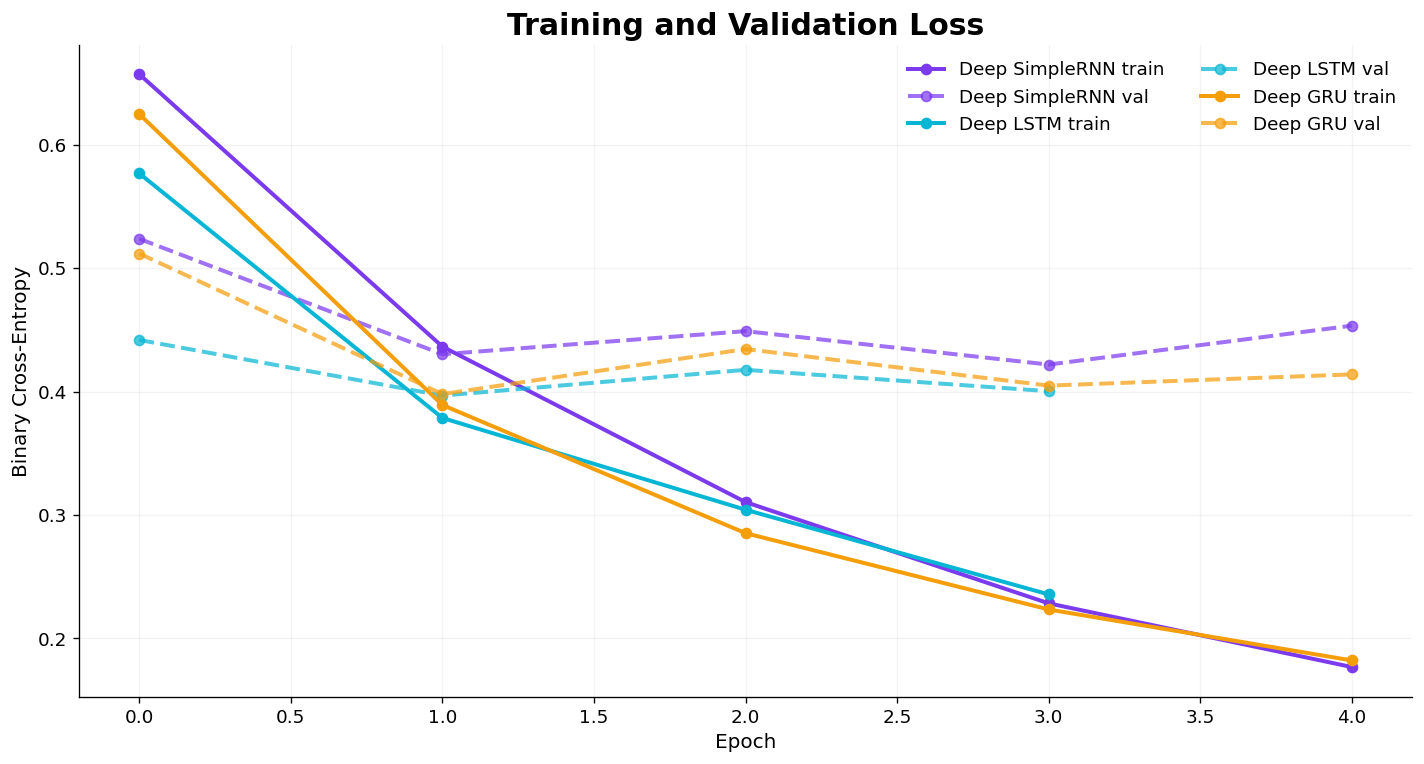

In [14]:
section("Learning Curves", "Accuracy and loss trajectories for the three deep recurrent models")

fig, ax = plt.subplots(figsize=(12, 6.5))

for color, (name, history) in zip(PALETTE[:3], histories.items()):
    ax.plot(
        history["accuracy"],
        marker="o",
        linewidth=2.4,
        color=color,
        label=f"{name} train"
    )

    ax.plot(
        history["val_accuracy"],
        marker="o",
        linewidth=2.4,
        linestyle="--",
        color=color,
        alpha=.72,
        label=f"{name} val"
    )

min_val_accuracy = min(
    min(history["val_accuracy"])
    for history in histories.values()
)

ax.set_title("Training and Validation Accuracy", fontsize=18, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.45, min(0.9, min_val_accuracy - 0.05)), 1.0)
ax.legend(ncol=2, frameon=False)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 6.5))

for color, (name, history) in zip(PALETTE[:3], histories.items()):
    ax.plot(
        history["loss"],
        marker="o",
        linewidth=2.4,
        color=color,
        label=f"{name} train"
    )

    ax.plot(
        history["val_loss"],
        marker="o",
        linewidth=2.4,
        linestyle="--",
        color=color,
        alpha=.72,
        label=f"{name} val"
    )

ax.set_title("Training and Validation Loss", fontsize=18, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy")
ax.legend(ncol=2, frameon=False)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

,accuracy,auc,loss,training_minutes
Deep SimpleRNN,0.8263,0.8886,0.4305,0.46
Deep LSTM,0.8293,0.9094,0.4020,0.28
Deep GRU,0.8350,0.9108,0.4224,0.28


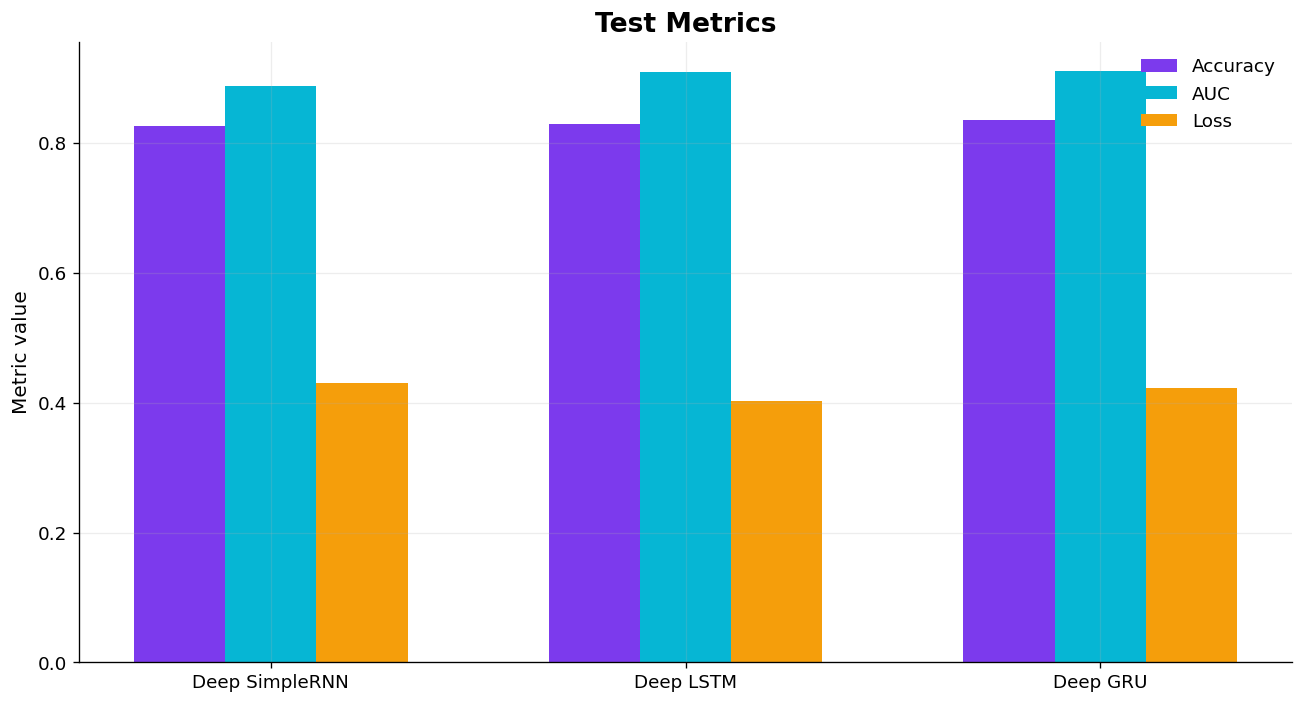

In [15]:

section("Final Evaluation", "Test-set accuracy, AUC, loss and training time")

evaluation = {}
for name, model in models.items():
    values = model.evaluate(x_test, np.asarray(y_test), batch_size=BATCH_SIZE, verbose=0, return_dict=True)
    values["training_minutes"] = timings[name] / 60
    evaluation[name] = values

evaluation_df = pd.DataFrame(evaluation).T
display(evaluation_df.style.format({
    "loss": "{:.4f}",
    "accuracy": "{:.4f}",
    "auc": "{:.4f}",
    "training_minutes": "{:.2f}"
}))

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(evaluation_df))
width = .22
ax.bar(x-width, evaluation_df["accuracy"], width, label="Accuracy", color=PALETTE[0])
ax.bar(x, evaluation_df["auc"], width, label="AUC", color=PALETTE[1])
ax.bar(x+width, evaluation_df["loss"], width, label="Loss", color=PALETTE[2])
ax.set_xticks(x)
ax.set_xticklabels(evaluation_df.index)
ax.set_title("Test Metrics")
ax.set_ylabel("Metric value")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1871/1767003674.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


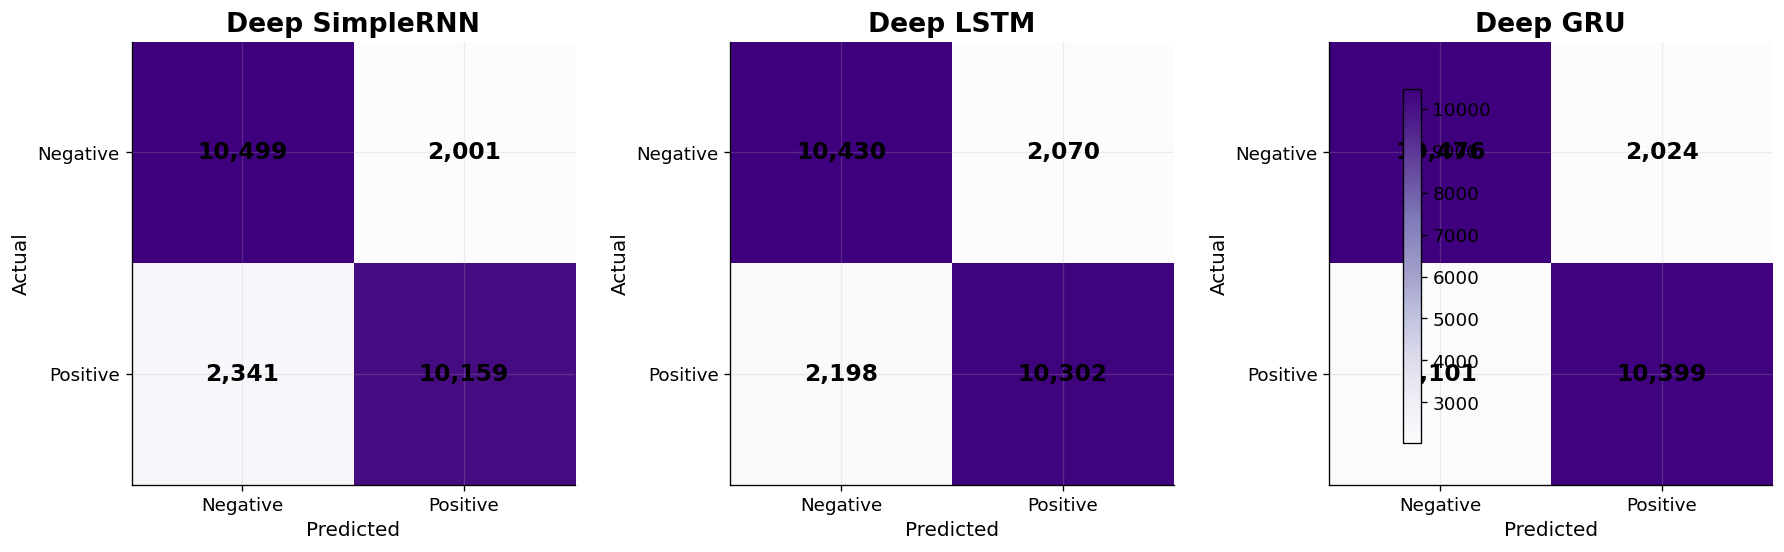

In [16]:

section("Confusion Matrices", "Thresholding sigmoid predictions at 0.5")

def confusion_values(y_true, y_prob, threshold=.5):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tn = np.sum((y_true==0)&(y_pred==0))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    tp = np.sum((y_true==1)&(y_pred==1))
    return np.array([[tn, fp], [fn, tp]])

predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0).ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (name, probs) in zip(axes, predictions.items()):
    cm = confusion_values(y_test, probs)
    im = ax.imshow(cm, cmap="Purples")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1], ["Negative","Positive"])
    ax.set_yticks([0,1], ["Negative","Positive"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=.8)
plt.tight_layout()
plt.show()


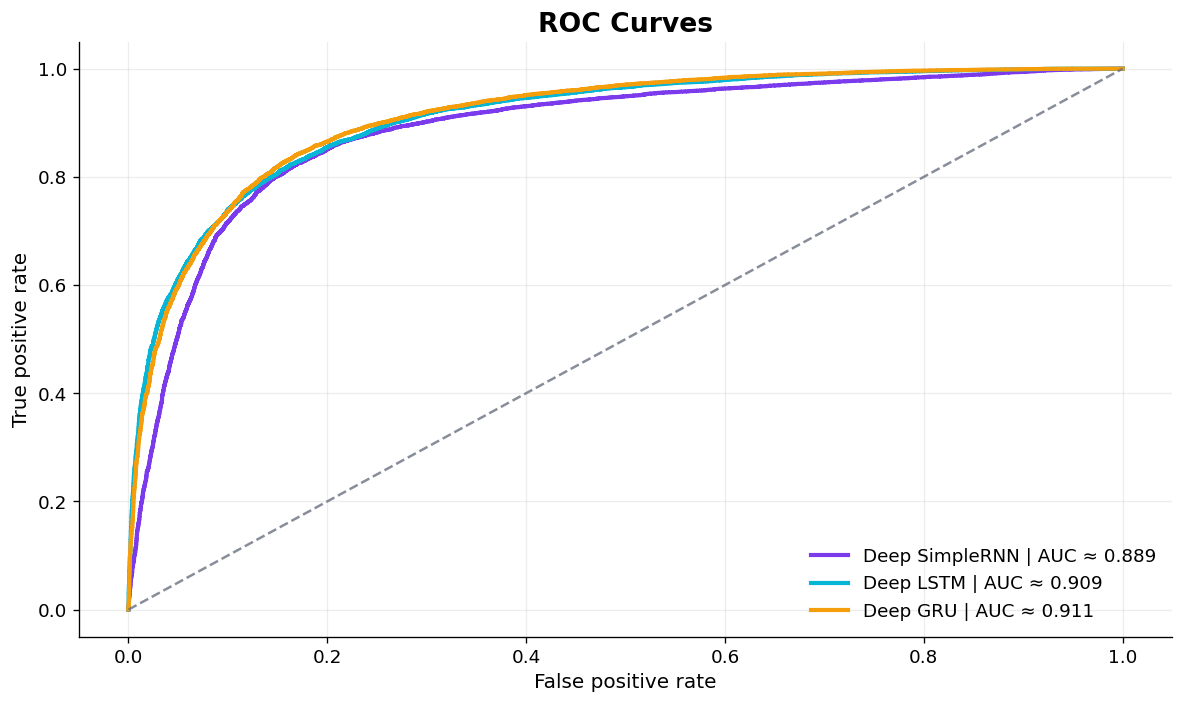

In [17]:

section("ROC Curves", "A threshold-independent view of binary classification quality")

def roc_points(y_true, scores):
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-scores)
    y_sorted = y_true[order]
    s_sorted = scores[order]
    positives = np.sum(y_true == 1)
    negatives = np.sum(y_true == 0)
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)
    distinct = np.r_[True, s_sorted[1:] != s_sorted[:-1]]
    tpr = np.r_[0, (tp[distinct] / max(positives, 1)), 1]
    fpr = np.r_[0, (fp[distinct] / max(negatives, 1)), 1]
    return fpr, tpr

fig, ax = plt.subplots(figsize=(10, 6))
for color, (name, probs) in zip(PALETTE[:3], predictions.items()):
    fpr, tpr = roc_points(y_test, probs)
    auc_value = np.trapezoid(tpr, fpr)
    ax.plot(fpr, tpr, linewidth=2.5, color=color, label=f"{name} | AUC ≈ {auc_value:.3f}")
ax.plot([0,1], [0,1], linestyle="--", linewidth=1.5, color="#6B7280", alpha=.8)
ax.set_title("ROC Curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


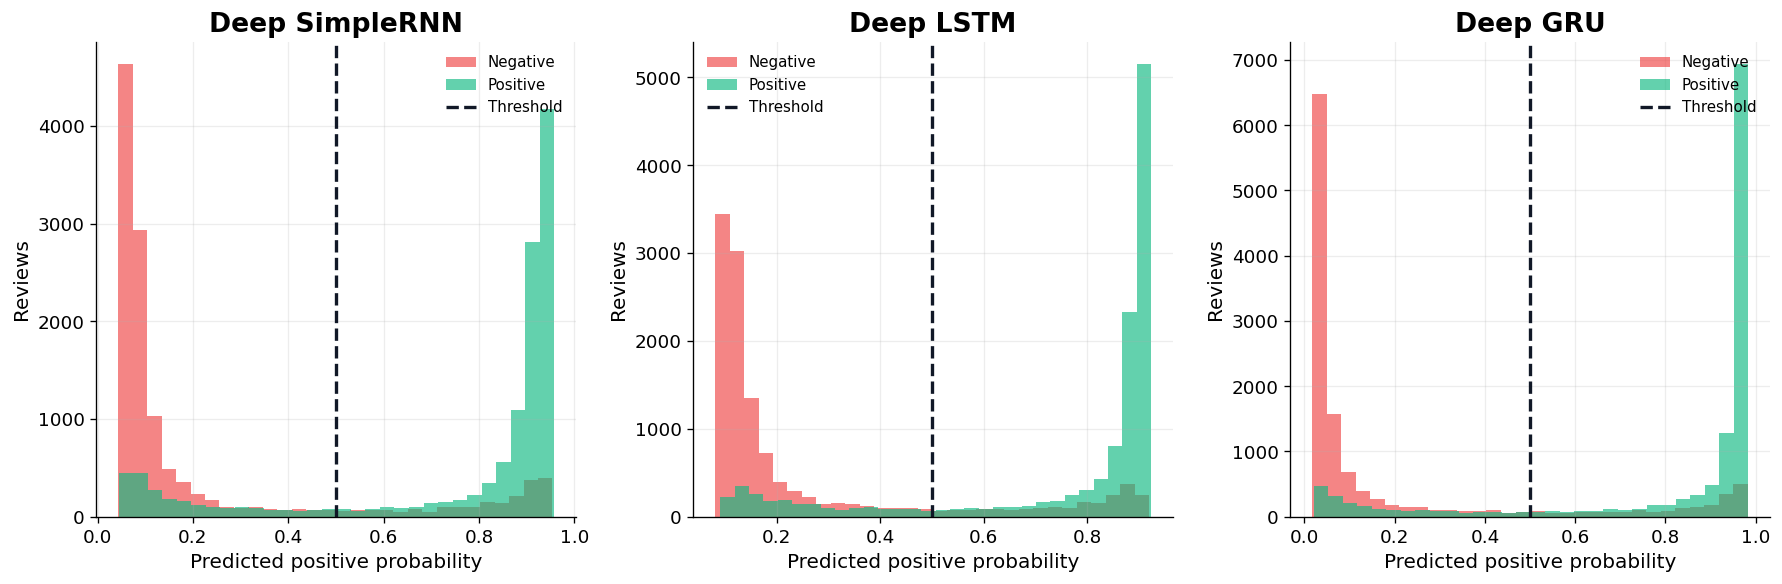

In [18]:

section("Prediction Confidence", "Probability distributions on the held-out test set")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, probs) in zip(axes, predictions.items()):
    ax.hist(probs[y_test==0], bins=30, alpha=.65, color=PALETTE[3], label="Negative")
    ax.hist(probs[y_test==1], bins=30, alpha=.65, color=PALETTE[4], label="Positive")
    ax.axvline(.5, linestyle="--", linewidth=2, color="#111827", label="Threshold")
    ax.set_title(name)
    ax.set_xlabel("Predicted positive probability")
    ax.set_ylabel("Reviews")
    ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


In [19]:

section("Sample Predictions", "Readable reviews paired with predicted sentiment and confidence")

display_rows = []
for idx in [10, 25, 50, 75, 100]:
    text_value = decode_review(x_test[idx])[:420]
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    row = {"Review": text_value, "Actual": true_label}
    for name, probs in predictions.items():
        p = float(probs[idx])
        row[name] = f"{'Positive' if p >= .5 else 'Negative'} ({p:.2%})"
    display_rows.append(row)

display(pd.DataFrame(display_rows).style.set_properties(**{"text-align":"left"}))


,Review,Actual,Deep SimpleRNN,Deep LSTM,Deep GRU
0,and is now being as a great new author even appearing on the oprah show to in he should be enjoying thus gets the idea of murders to rid themselves of these factors br br of course everything and anything can happen when writer carl lets his imagination with ideas for how the plot develops and it's amusing all the way through providing plenty of laughs and chuckles alon,Positive,Positive (89.63%),Positive (90.05%),Positive (94.94%)
1,up the box office and all horror fans should have part in it go see house of wax the film that features skin being super glued lips dead animal hot wax on a still living person a finger being cut off a a pole through the head and much more i was lucky enough to witness this film at the premiere and all the actors were on hand to promote the film and boy do they have something to be proud,Positive,Positive (92.30%),Positive (69.99%),Positive (98.06%)
2,you into your hearts but really it ended and i felt like i had watched a 5 minute cartoon on kids tv br br i don't have children of my own but when i do i fully intend to show them quality children's movies like the movie toy story and finding even though they are too childish for me these days i can see how they would be of great appeal to young children not so with this appalling attempt at a movie br br oh a,Negative,Negative (6.78%),Negative (10.69%),Negative (4.01%)
3,extras from star wars br br 5 if you need to pad your crappy movie's runtime the title sequence by adding star trek style credits and throw in some overly music it also helps if you've got a previous movie to pull scenes from br br 6 fight scenes move along much if the bad guys attack one at a time br br 7 william did anything for money br br 8 i didn't think it was possible but the adve,Negative,Positive (68.05%),Positive (74.59%),Positive (97.98%)
4,you actually want to die however delivers considerably more br br rather than focus on bare flesh and gore though there is a little of each no sex however the flick focuses on delivering impending dread tension amidst a lovely backdrop these feelings are further by a cast of realistically likable characters and that are more amoral than cardboard of evil oh yeah george kennedy is here to,Positive,Negative (22.66%),Negative (13.07%),Negative (26.71%)


,Architecture,Shallow params,Deep params,Additional params,Multiplier
0,SimpleRNN,"320,196","320,251",55,1.00x
1,LSTM,"320,766","320,986",220,1.00x
2,GRU,"320,591","320,771",180,1.00x


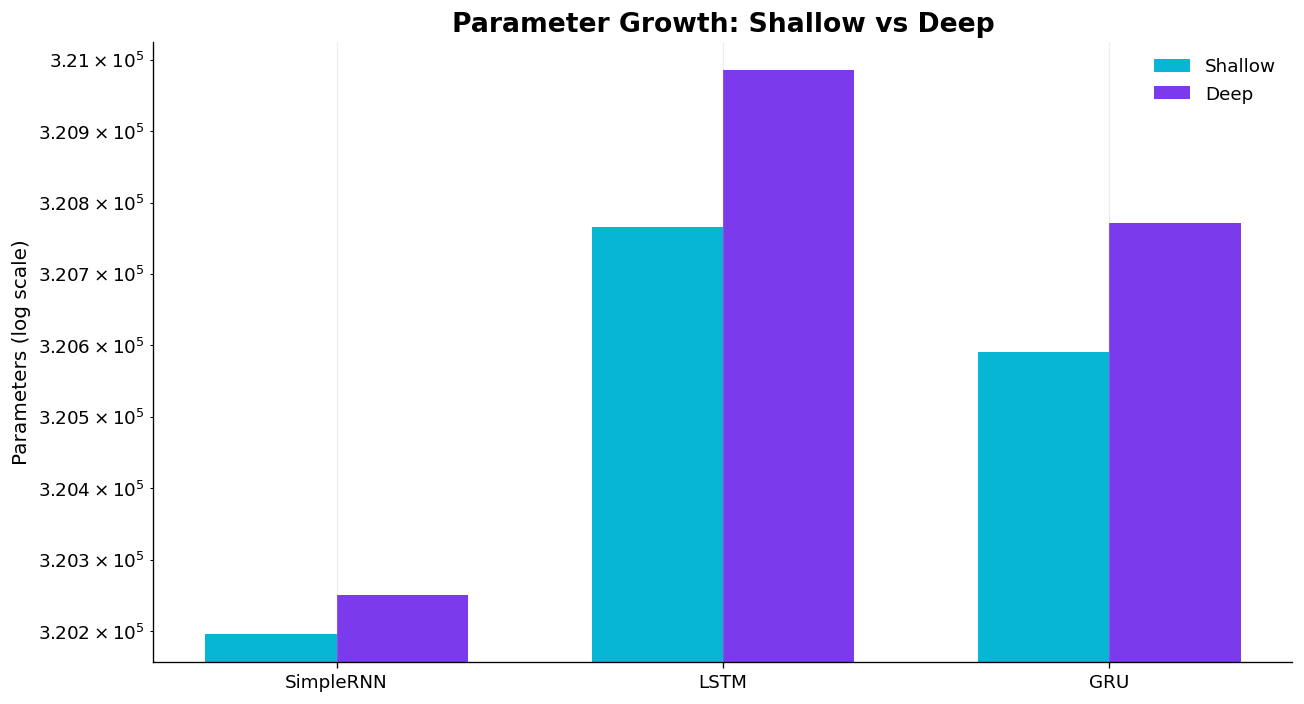

In [20]:

section("Deep vs Shallow Parameter Growth", "The stacked design adds recurrent transformations while keeping the same sequence length")

def build_shallow_model(kind, name):
    recurrent = {
        "SimpleRNN": layers.SimpleRNN,
        "LSTM": layers.LSTM,
        "GRU": layers.GRU
    }[kind]
    inputs = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
    x = recurrent(UNITS)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, outputs, name=name)
    return model

growth_rows = []
for kind, deep_name in [("SimpleRNN","Deep SimpleRNN"),("LSTM","Deep LSTM"),("GRU","Deep GRU")]:
    shallow = build_shallow_model(kind, f"shallow_{kind.lower()}")
    deep = models[deep_name]
    growth_rows.append({
        "Architecture": kind,
        "Shallow params": shallow.count_params(),
        "Deep params": deep.count_params(),
        "Additional params": deep.count_params()-shallow.count_params(),
        "Multiplier": deep.count_params()/shallow.count_params()
    })

growth_df = pd.DataFrame(growth_rows)
display(growth_df.style.format({
    "Shallow params":"{:,}",
    "Deep params":"{:,}",
    "Additional params":"{:,}",
    "Multiplier":"{:.2f}x"
}))

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(growth_df))
width = .34
ax.bar(x-width/2, growth_df["Shallow params"], width, label="Shallow", color=PALETTE[1])
ax.bar(x+width/2, growth_df["Deep params"], width, label="Deep", color=PALETTE[0])
ax.set_xticks(x)
ax.set_xticklabels(growth_df["Architecture"])
ax.set_yscale("log")
ax.set_title("Parameter Growth: Shallow vs Deep")
ax.set_ylabel("Parameters (log scale)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [21]:

section("Optional Shallow Baselines", "Run this cell only when you want a direct shallow-versus-deep benchmark")

if RUN_BASELINES:
    baseline_models = {
        "SimpleRNN": build_shallow_model("SimpleRNN", "shallow_simplernn"),
        "LSTM": build_shallow_model("LSTM", "shallow_lstm"),
        "GRU": build_shallow_model("GRU", "shallow_gru")
    }
    baseline_history = {}
    for name, model in baseline_models.items():
        print(name)
        baseline_history[name] = model.fit(
            x_fit, y_fit,
            validation_data=(x_val, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks_factory(),
            verbose=1
        ).history
    baseline_eval = {}
    for name, model in baseline_models.items():
        baseline_eval[name] = model.evaluate(x_test, np.asarray(y_test), batch_size=BATCH_SIZE, verbose=0, return_dict=True)
    display(pd.DataFrame(baseline_eval).T.style.format("{:.4f}"))
else:
    print("RUN_BASELINES is False. Change it to True before running this cell to train shallow baselines.")


RUN_BASELINES is False. Change it to True before running this cell to train shallow baselines.


In [22]:

section("Save Trained Models", "Reusable .keras files with the same architecture and learned weights")

save_dir = os.path.join(os.getcwd(), "deep_rnn_models")
os.makedirs(save_dir, exist_ok=True)

saved_paths = {}
for name, model in models.items():
    filename = name.lower().replace(" ", "_") + ".keras"
    path = os.path.join(save_dir, filename)
    model.save(path)
    saved_paths[name] = path

for name, path in saved_paths.items():
    print(f"{name}: {path}")


Deep SimpleRNN: /content/deep_rnn_models/deep_simplernn.keras
Deep LSTM: /content/deep_rnn_models/deep_lstm.keras
Deep GRU: /content/deep_rnn_models/deep_gru.keras


In [23]:

section("Export Results", "Save evaluation tables and prediction probabilities for later analysis")

results_dir = os.path.join(os.getcwd(), "deep_rnn_results")
os.makedirs(results_dir, exist_ok=True)

evaluation_df.to_csv(os.path.join(results_dir, "model_evaluation.csv"))
growth_df.to_csv(os.path.join(results_dir, "parameter_growth.csv"), index=False)

for name, probs in predictions.items():
    safe_name = name.lower().replace(" ", "_")
    pd.DataFrame({
        "actual": np.asarray(y_test).astype(int),
        "predicted_probability": probs,
        "predicted_label": (probs >= .5).astype(int)
    }).to_csv(os.path.join(results_dir, f"{safe_name}_predictions.csv"), index=False)

print(f"Models: {save_dir}")
print(f"Results: {results_dir}")


Models: /content/deep_rnn_models
Results: /content/deep_rnn_results


In [24]:

section("Experiment Snapshot", "A compact view of the final run")

best_accuracy_name = evaluation_df["accuracy"].idxmax()
best_auc_name = evaluation_df["auc"].idxmax()

metric_cards([
    ("Highest test accuracy", f"{best_accuracy_name}: {evaluation_df.loc[best_accuracy_name, 'accuracy']:.3f}"),
    ("Highest test AUC", f"{best_auc_name}: {evaluation_df.loc[best_auc_name, 'auc']:.3f}"),
    ("Deep models trained", len(models)),
    ("Sequence length", MAX_LEN)
])

print(evaluation_df.round(4))


                accuracy     auc    loss  training_minutes
Deep SimpleRNN    0.8263  0.8886  0.4305            0.4609
Deep LSTM         0.8293  0.9094  0.4020            0.2809
Deep GRU          0.8350  0.9108  0.4224            0.2756
